# 👩‍💻 Customer Segmentation with K-Means Clustering

## 📋 Overview
In this lab, you’ll apply **K-Means Clustering** to the **Mall Customer Segmentation Dataset**. You’ll experiment with different numbers of clusters, use the **Elbow Method** to find the best K, visualize your results, and interpret meaningful customer segments based on real purchasing behavior.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Preprocess real-world datasets for clustering
 
- Apply K-Means clustering with multiple K values
 
- Use the Elbow Method to find an optimal K
 
- Visualize and interpret customer segments

## Task 1: Load and Explore the Dataset 
**Context:** Always start with understanding your data before modeling.

**Steps:**

1. Load `Mall_Customers.csv `using Pandas.
2. Use`.head()`, `.info()`, and `.describe()` to inspect structure and summary statistics.
3. Focus on `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`.

**Prompting Questions:**

- Are the relevant features clean and properly formatted?
- Are there obvious patterns or groupings already?


💡 **Tip:** Remember: K-Means is sensitive to feature scale

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv('Mall_Customers.csv')

# Preview the data
# <your code here>
print(data.shape)
data.head(2)

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [3]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [5]:
print(data['Gender'].value_counts(dropna=False))
print(data['Gender'].value_counts(dropna=False, normalize=True))

Female    112
Male       88
Name: Gender, dtype: int64
Female    0.56
Male      0.44
Name: Gender, dtype: float64


In [6]:
# Focus on selected features
features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

⚙️ **Test Your Work:**

- DataFrame loads correctly with expected columns


## Task 2: Data Preprocessing 
**Context:** K-Means clustering assumes features are scaled similarly.

**Steps:**

1. Check for missing values (`.isnull().sum()`).
2. Standardize `Age`,` Annual Income (k$)`, and `Spending Score (1-100)` using `StandardScaler`.
3. Create a new scaled features DataFrame (`X_scaled`).

**Prompting Questions:**
- Are any features heavily skewed or scaled differently?

💡 **Tip:** Use `StandardScaler()` from `sklearn.preprocessing`.

In [7]:
print(features.isnull().sum())

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [8]:
# Standardize features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

⚙️ **Test Your Work:**

`X_scaled` has mean 0 and standard deviation 1 across features

## Task 3: Implement the Elbow Method to Determine K
**Context:** Choosing the right number of clusters is crucial.

**Steps:**

1. Train K-Means models with a range of K values (e.g., 1 to 10).
2.  Store and plot the inertia (within-cluster sum of squares) for each K.
3.  Identify the "elbow" point visually where inertia starts decreasing more slowly.

**Prompting Questions:**

- Where does the plot flatten out noticeably?
- What K seems to best balance simplicity and accuracy?


💡 **Tip:** The elbow point is where adding another cluster doesn’t improve much.

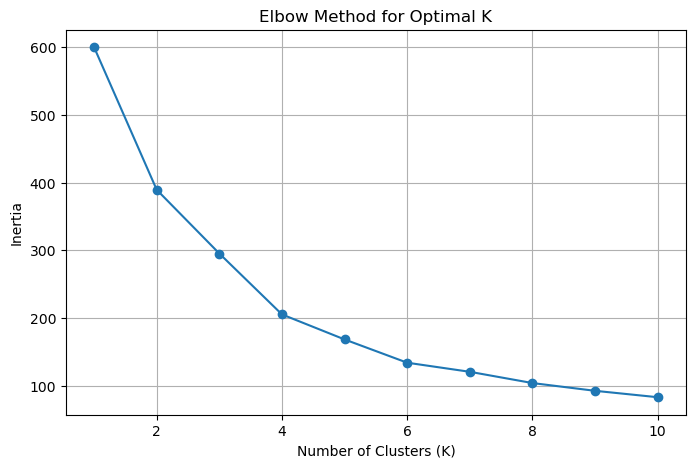

In [9]:
# Implement elbow method for KMeans clustering

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

⚙️ **Test Your Work:**

- Inertia vs K plot is created
- An elbow point should be visible in the plot, suggesting a potential optimal K value.

## Task 4: Apply K-Means Clustering
**Context:** Now apply K-Means using your chosen K value.

**Steps:**

1. Train a KMeans model using the selected optimal K.
2. Predict cluster labels for each customer.
3. Add these cluster labels to your DataFrame.

**Prompting Questions:**

- Are the clusters evenly sized?
- Do cluster centers seem reasonable?


💡 **Tip:** Set `random_state=42` for reproducibility.

In [10]:
# Train final KMeans model and assign cluster labels

optimal_k = 5

# Train final KMeans model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original data
data['Cluster'] = cluster_labels

⚙️ **Test Your Work:**
    
- DataFrame has new `Cluster` column
- No major errors or extreme cluster sizes


## Task 5: Visualize the Clusters 
**Context:** See your clustering visually to validate it intuitively.

**Steps:**

1. Create scatter plots using two principal features (e.g., Income vs Spending Score).
2. Color points based on cluster labels.
3. Plot cluster centroids as larger markers.

**Prompting Questions:**

- Are clusters tight and separated?
- Do centroids lie near cluster centers?


💡 **Tip:** Use different colors and legend labels for each cluster.

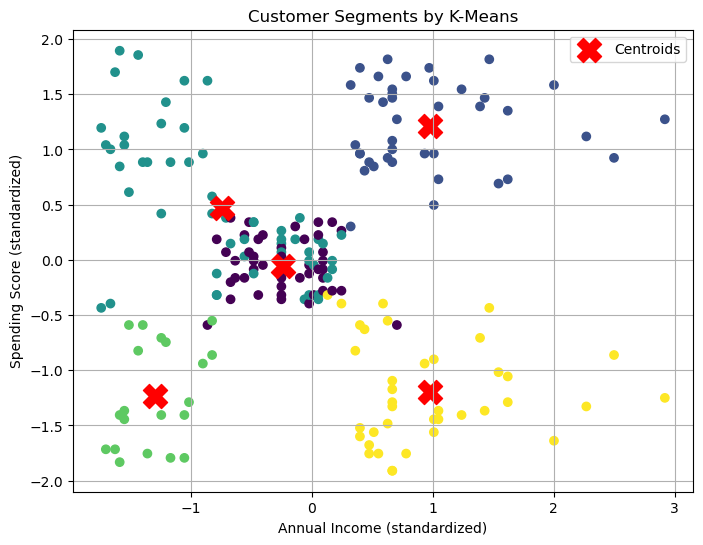

In [12]:
# Visualize clusters and centroids using matplotlib

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_scaled[:,1],  # Annual Income (standardized)
    X_scaled[:,2],  # Spending Score (standardized)
    c=cluster_labels, 
    cmap='viridis'
)

# Plot centroids
plt.scatter(
    kmeans_final.cluster_centers_[:,1],
    kmeans_final.cluster_centers_[:,2],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments by K-Means')
plt.xlabel('Annual Income (standardized)')
plt.ylabel('Spending Score (standardized)')
plt.legend()
plt.grid(True)
plt.show()

⚙️ **Test Your Work:**
    
- Distinct clusters visible in scatter plot
- Centroids plotted and correctly positioned


## Task 6: Interpret the Clusters
**Context:** Turn technical results into business insights.

**Steps:**

1. Summarize each cluster:
   - High Income, High Spending
   - Low Income, High Spending
   - etc.

2. Reflect on how each group might be targeted differently by marketing teams.

**Prompting Questions:**

- Which clusters are ideal targets for promotions?

- Which clusters might need retention strategies?


💡 **Tip:** Think about customer "personas" emerging from clusters.

In [ ]:
#Task 6: Interpret the Clusters

**Cluster Interpretation :**
- Cluster 0: High income, high spending customers
- Cluster 1: Lower income, lower spending customers
- Cluster 2: High income, moderate spending
- Cluster 3: Younger customers with high spending
- Cluster 4: Moderate income and moderate spending

**Insights :**
- High spenders could be targeted for premium loyalty programs.
- Low income, low spenders might need budget-focused promotions.
- Younger high spenders could be targeted for trendy or luxury products.

## ✅ Success Checklist

- Dataset loaded and inspected
- Data standardized for clustering
- Elbow Method plot created and interpreted
- K-Means model trained and clusters assigned
- Visualizations of clusters and centroids created
- Business insights about clusters documented


## 🔍 Common Issues & Solutions

**Problem:** K-Means clustering not converging

**Solution:** Increase `max_iter` in `KMeans()`
 
**Problem:** Elbow point hard to spot

**Solution:** Try zooming into the plot or rerun with slightly larger K range
 
**Problem:** All points assigned to one cluster

**Solution:** Double-check scaling — features must be standardized

## 🔑 Key Points

- K-Means requires properly scaled features
- The Elbow Method helps choose an optimal K
- Clustering can reveal actionable customer segments for targeted marketing

## 💻 Exemplar Solution
After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches.
Reflect on what you can learn from the exemplar solution to improve your coding skills.
Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches.
Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.

<details>

<summary><strong>Click HERE to see an exemplar solution</strong></summary>    
    
```python
# -------------------------------
# Task 1: Load and Explore Dataset
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv('Mall_Customers.csv')

# Preview the dataset
print(data.head())
print(data.info())
print(data.describe())

# Focus on selected features
features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# -------------------------------
# Task 2: Data Preprocessing
# -------------------------------

# Check for missing values
print(features.isnull().sum())

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# -------------------------------
# Task 3: Implement Elbow Method
# -------------------------------

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# -------------------------------
# Task 4: Apply K-Means Clustering
# -------------------------------

# Assuming from Elbow method K=5. Depending on the trials and elbow point, this can be updated.
optimal_k = 5

# Train final KMeans model
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original data
data['Cluster'] = cluster_labels

# -------------------------------
# Task 5: Visualize the Clusters
# -------------------------------

# Plot Income vs Spending Score colored by cluster
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_scaled[:,1],  # Annual Income (standardized)
    X_scaled[:,2],  # Spending Score (standardized)
    c=cluster_labels, 
    cmap='viridis'
)

# Plot centroids
plt.scatter(
    kmeans_final.cluster_centers_[:,1],
    kmeans_final.cluster_centers_[:,2],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments by K-Means')
plt.xlabel('Annual Income (standardized)')
plt.ylabel('Spending Score (standardized)')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Task 6: Interpret the Clusters
# -------------------------------

"""Cluster Interpretation:
- Cluster 0: High income, high spending customers
- Cluster 1: Lower income, lower spending customers
- Cluster 2: High income, moderate spending
- Cluster 3: Younger customers with high spending
- Cluster 4: Moderate income and moderate spending
Insights:
- High spenders could be targeted for premium loyalty programs.
- Low income, low spenders might need budget-focused promotions.
- Younger high spenders could be targeted for trendy or luxury products.
"""
``` 